# Determinants of Video Game Success: A Data-Driven Market Analysis

<a id='1'></a>
### Project description, data, definition of goals and objectives ###

I am working as an analyst at the online store “Strymchik,” which sells computer games worldwide.

Historical data on game sales, user and expert ratings, genres, and platforms (for example, Xbox or PlayStation) are available from open sources.

It is necessary to identify patterns that determine a game’s success. This will allow us to bet on a potentially popular product and plan advertising campaigns.

We have data up to 2016. Let’s assume it is now December 2016, and we are planning a campaign for 2017.

The aim is to establish a working approach with the data.

The dataset includes the abbreviation ESRB (Entertainment Software Rating Board) — an association that determines the age rating of computer games. ESRB evaluates game content and assigns it an appropriate age category, for example, “Mature,” “Early Childhood,” or “Teen.”

**Import the required libraries**

In [1]:
import pandas as pd
import numpy as np

from scipy import stats as st

import matplotlib.pyplot as plt
import seaborn as sns

### Step 1. Open the data file and explore general information

In [6]:
df = pd.read_csv('/Users/dianasalnikova/Downloads/games.csv')

In [7]:
df.info()
print(df.describe())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
       Year_of_Release      NA_sales      EU_sales      JP_sales  \
count     16446.000000  16715.000000  16715.000000  16715.000000   
mean       2006.484616      0.263377      0.145060      0.077617   
std           5.877050      0.813604 

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


The general information about the data shows that there are missing values in the dataframe, and some columns require a data type change.
The data needs to be adjusted during the preprocessing stage.

### Step 2. Prepare the data

#### - Renaming columns

Let’s convert the column names to lowercase. We will also convert the values in the "name" column to lowercase to simplify the search for duplicates.

In [8]:
df.columns = df.columns.str.lower()
df.name = df.name.str.lower()

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,super mario bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,mario kart wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,wii sports resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,pokemon red/pokemon blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### - Handling missing values

In [9]:
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

There are many missing values in the dataset; they need to be handled to make working with the data more convenient.

- Missing values in the "name" column should simply be removed. If we do not even know the name of the game, why would we need any other information about it? Moreover, there are only 2 missing values, which is an insignificant amount of data, so they can be deleted.

- Missing values in "year_of_release" can also be removed. If we look at the rows with these missing values, we will see that the rating, critic score, and user score are also missing there. The share of missing values is about 1.6% — they can be removed.

- In the "user_score" column there are values "tbd" (to be determined). These should be replaced with missing values so that the statistics are calculated correctly.

- The remaining missing values can be left unchanged.

In [10]:
df = df.dropna(subset=['name'])
df = df.dropna(subset=['year_of_release'])
df.loc[df['user_score'] == 'tbd', 'user_score'] = np.nan
df['rating'] = df['rating'].fillna('not mentioned')

df.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64

Missing values in the dataset may be caused by human factors: someone intentionally or accidentally did not provide certain information. There may also be organizational reasons — for example, some information may need to remain confidential. Missing values can also result from software errors or hardware failures.

#### - Handling duplicates

- Exact duplicates

Let’s identify exact duplicates. We will search based on three columns ("name", "platform", "year_of_release"). This is because the dataset was compiled from different sources, and different sources may contain different ratings.

In [11]:
df[df[['name', 'platform', 'year_of_release']].duplicated(keep=False)]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,madden nfl 13,PS3,2012.0,Sports,2.11,0.22,0.0,0.23,83.0,5.5,E
16230,madden nfl 13,PS3,2012.0,Sports,0.00,0.01,0.0,0.00,83.0,5.5,E


Let’s remove the duplicates and update the indices after deletion:

In [12]:
df.drop(df[df[['name', 'platform', 'year_of_release']].duplicated(keep=False)].index, inplace=True)

In [13]:
df.reset_index(drop=True)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,super mario bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,not mentioned
2,mario kart wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,wii sports resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,pokemon red/pokemon blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,not mentioned
...,...,...,...,...,...,...,...,...,...,...,...
16437,samurai warriors: sanada maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,not mentioned
16438,lma manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,not mentioned
16439,haitaka no psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,not mentioned
16440,spirits & spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,not mentioned


- Partial duplicates

In [10]:
df['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [11]:
df['genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

By displaying the list of unique values in the platform and genre columns, we can see that there are no partial duplicates. To eliminate partial duplicates in the "name" column, I have converted all values in this column to lowercase at the stage of renaming the columns.

#### - Data type conversion

Some columns have incorrect data types and need to be changed.

- The "year_of_release" column has the float data type. It should be converted to int, but this is not possible due to missing values in the data. In this case, it is a minor issue, and we can still work with the data.

- In the "user_score" column, the data type needs to be converted to float.

In [14]:
df['user_score'] = df['user_score'].astype('float')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16442 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16442 non-null  object 
 1   platform         16442 non-null  object 
 2   year_of_release  16442 non-null  float64
 3   genre            16442 non-null  object 
 4   na_sales         16442 non-null  float64
 5   eu_sales         16442 non-null  float64
 6   jp_sales         16442 non-null  float64
 7   other_sales      16442 non-null  float64
 8   critic_score     7981 non-null   float64
 9   user_score       7461 non-null   float64
 10  rating           16442 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.5+ MB


#### - Total sales across all regions

Let’s create a new column with total sales across all regions:

In [15]:
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

#### - Conclusion

Data preprocessing (for each column) has been completed. The following actions were performed:
- Column names were converted to lowercase. This helps standardize the naming and makes them more convenient (readable) for further work with the data.

- Some columns were converted to the appropriate data type.

- Missing values were removed where possible. In all other cases, filling missing values was difficult, so those rows were left unchanged.

- Duplicates were removed from the dataset.

Thus, after completing the preprocessing of the computer game sales data, we obtained a cleaned dataset that can be used for further exploratory analysis.

In [16]:
# Let’s see what remains
temp = df.copy() 
list_c = ['name', 'platform', 'year_of_release', 'genre', 'critic_score', 'user_score', 'rating']
print(temp.info())
for col_l in list_c:
  print('-'* 25)
  print(col_l, temp[col_l].sort_values().unique())
  print(col_l,': кол-во NaN',temp[col_l].isna().sum(),
        ', процент NaN', round(temp[col_l].isna().mean()*100,2),'%') 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16442 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16442 non-null  object 
 1   platform         16442 non-null  object 
 2   year_of_release  16442 non-null  float64
 3   genre            16442 non-null  object 
 4   na_sales         16442 non-null  float64
 5   eu_sales         16442 non-null  float64
 6   jp_sales         16442 non-null  float64
 7   other_sales      16442 non-null  float64
 8   critic_score     7981 non-null   float64
 9   user_score       7461 non-null   float64
 10  rating           16442 non-null  object 
 11  total_sales      16442 non-null  float64
dtypes: float64(8), object(4)
memory usage: 1.6+ MB
None
-------------------------
name [' beyblade burst' ' fire emblem fates' " frozen: olaf's quest" ...
 'zwei!!' 'zyuden sentai kyoryuger: game de gaburincho!!'
 '¡shin chan flipa en colores!']


### Step 3. Exploratory data analysis

#### - How many games were released in different years

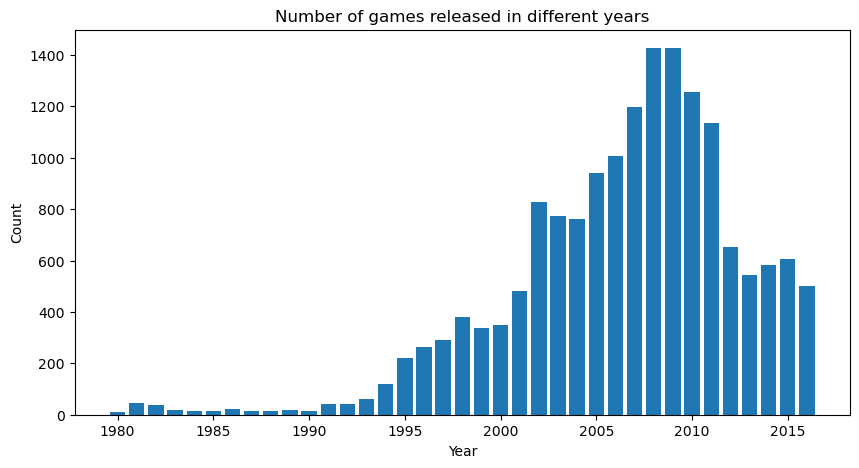

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(df.groupby('year_of_release')['name'].count().index, df.groupby('year_of_release')['name'].count().values)
plt.title('Number of games released in different years')
plt.xlabel('Year')
plt.ylabel('Count');

The chart shows that from 1980 to 1990, the number of released games remained almost unchanged and was very small. After 1990, more games began to be released, and their number grew until reaching a peak in 2008 and 2009. After that, the number of released games started to decline.

This means that people's interest in games increased from 1990 to 2008 and then began to decrease. Based on the graph, it can be concluded that it is important to analyze data across all periods.

#### - How sales changed across platforms

To track how sales changed across platforms, we first identify the 10 platforms that generated the highest total revenue. Let’s display them.

Then we create a pivot table grouped by platform and year, with total revenue values. After that, we keep only the rows where the platforms belong to the top 10 list. Finally, we build a chart.

In [18]:
platforms_top = df[df['year_of_release'].between(2012, 2016)].groupby(['platform'])['total_sales'].sum().sort_values(ascending=False)[:10]
platforms_top

platform
PS4     314.14
PS3     286.22
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64

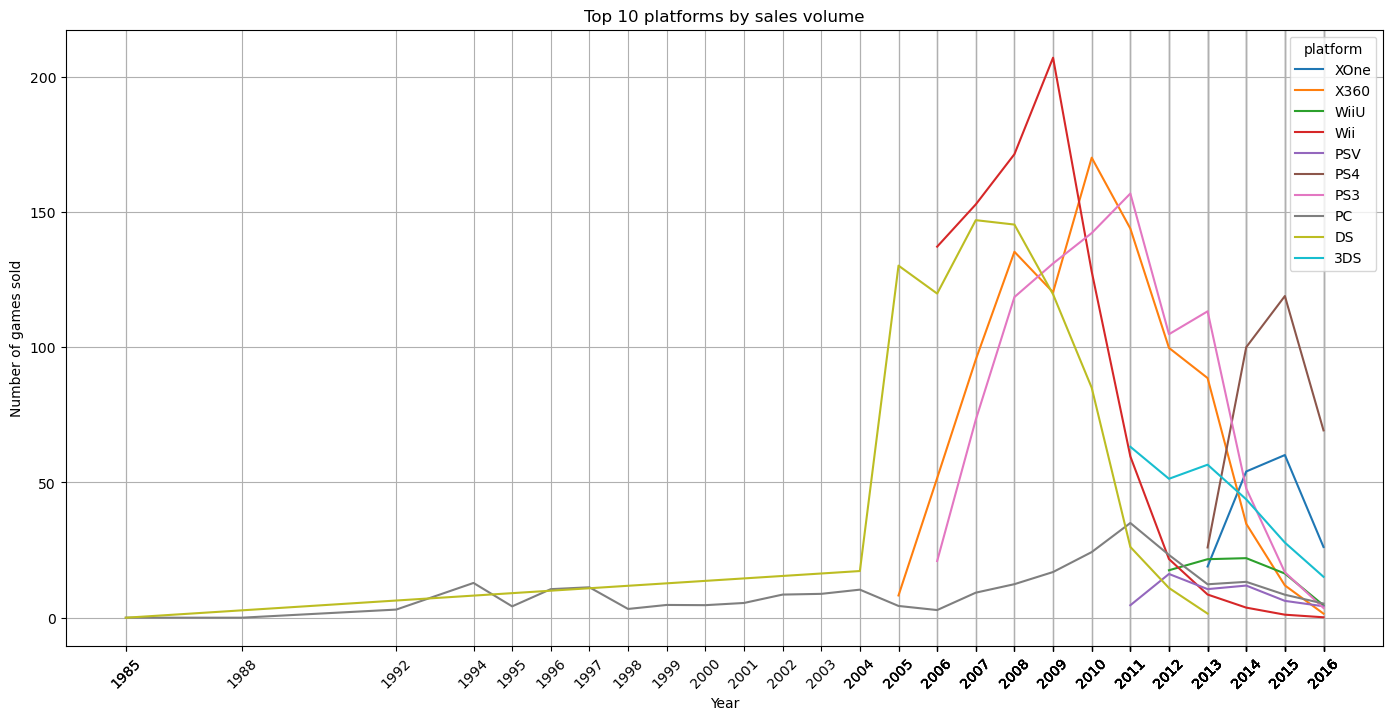

In [30]:
platforms = (df.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
             .sort_values(['platform', 'total_sales'], ascending=False))

platforms = platforms[platforms['platform'].isin(platforms_top.index)]

plt.figure(figsize = (17, 8))
sns.lineplot(data = platforms, x='year_of_release', 
             y='total_sales', hue='platform')
plt.grid()
plt.title('Top 10 platforms by sales volume')
plt.xlabel('Year')
plt.ylabel('Number of games sold')
plt.xticks(platforms['year_of_release'][::1], rotation = 45);

From the chart, we can see that typically around 7–9 years pass from the moment a platform appears until it disappears from the market. All sales distribution graphs for individual platforms look quite similar and have a distribution close to normal.

It can also be noted that the PS4, PS3, and X360 platforms have the highest sales levels.

The time a platform remains on the market can also be calculated using the table data:

In [20]:
temp = df.copy() 
time_life = temp.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
time_life['life'] = time_life['max'] - time_life['min'] + 1 # platform life cycle; the boundaries of the range should be included, 
                                                            # therefore +1
time_life['life'].median()

7.0

#### -  Determining the relevant period

For analyzing computer game sales and making a forecast for 2017, the last 5 years can be considered the relevant period because:

- 5 years is a sufficiently long period to observe market changes that allow for an accurate forecast.

- At the same time, it is not too long: as seen from the graph, the global market does not change dramatically within 5 years. Choosing such a time frame allows us to obtain relevant information and draw correct conclusions.

Let’s create a variable that contains data for the 10 most popular platforms over the selected relevant period and build a chart of sales changes across all platforms over the last 5 years:

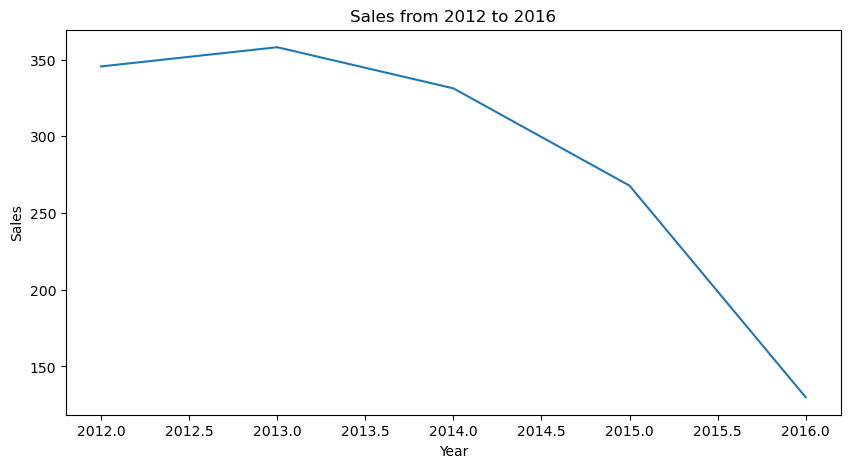

In [31]:
df_5_years = platforms[platforms['year_of_release'].between(2012, 2016)]

df_5_years.groupby('year_of_release')['total_sales'].sum().plot(use_index=True, 
                                                        title="Sales from 2012 to 2016", xlabel="Year", 
                                                        ylabel='Sales', figsize=(10, 5));

From the graph, we can see that the market is currently experiencing a decline in overall sales. The same trend is expected to continue in 2017.

#### - Which platforms lead in sales

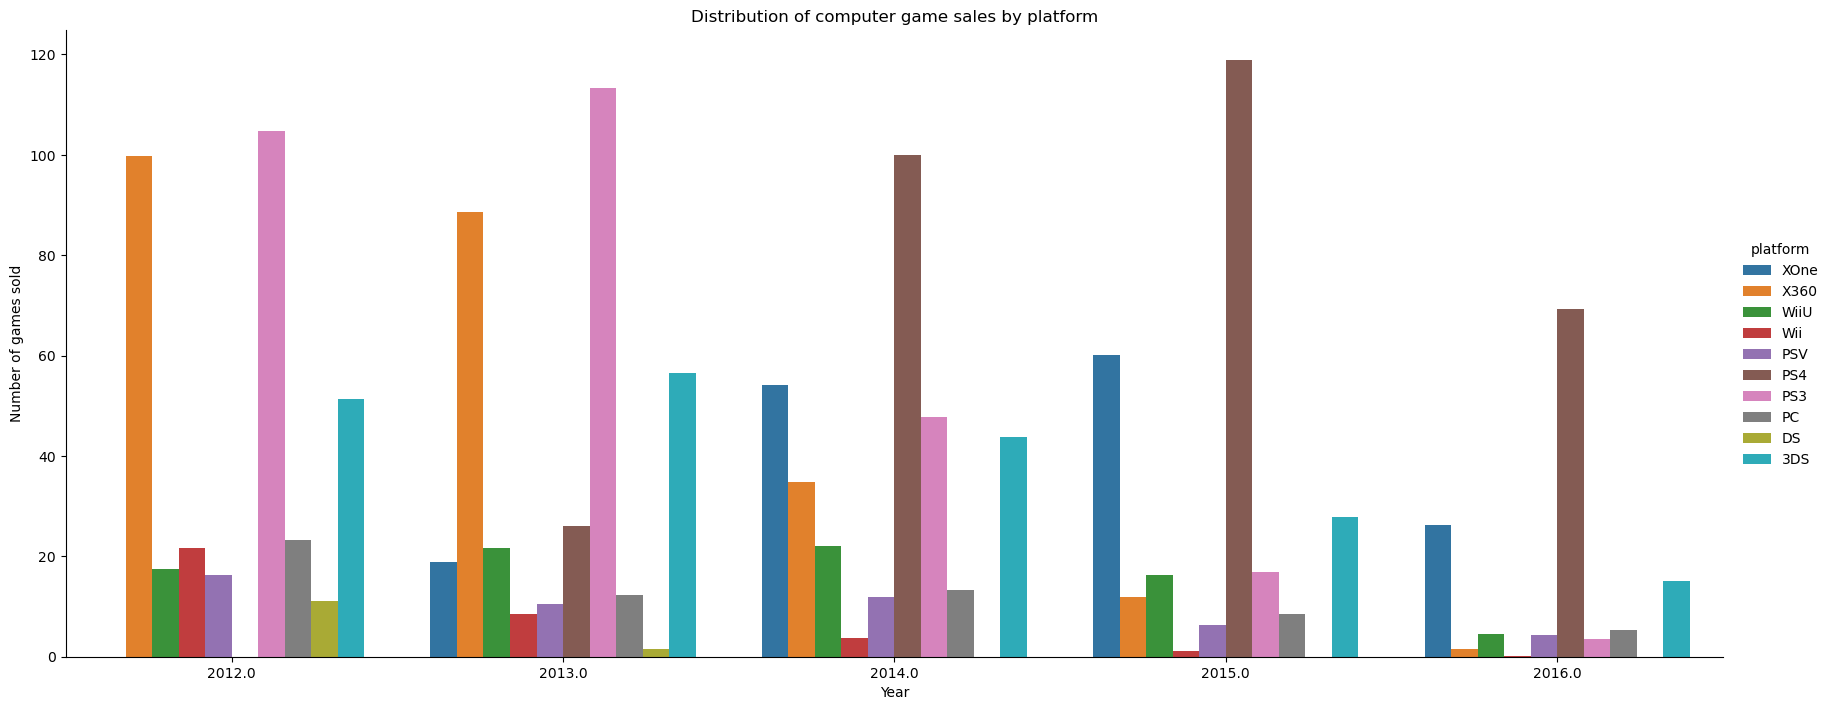

In [32]:
sns.catplot(x="year_of_release", y="total_sales", 
                 hue="platform", kind="bar", 
                 data=df_5_years, 
                 height=7, aspect=2.5)

plt.xlabel('Year')
plt.ylabel('Number of games sold')
plt.title('Distribution of computer game sales by platform');

From the graph, we can see that over the past 5 years the X360 and PS3 platforms have been losing popularity. The PS4 platform was gaining popularity until 2015, after which its sales declined by 2016, just like the XOne platform. PS4 is the most popular platform in 2016.

As a general conclusion, it can once again be emphasized that in 2016 all platforms are losing popularity, which indicates a decline in the popularity of games industry overall.

#### - Boxplots of global game sales by platform

Let’s build boxplots without prior aggregation by sum. For this, we create the variable "df_5_years1".

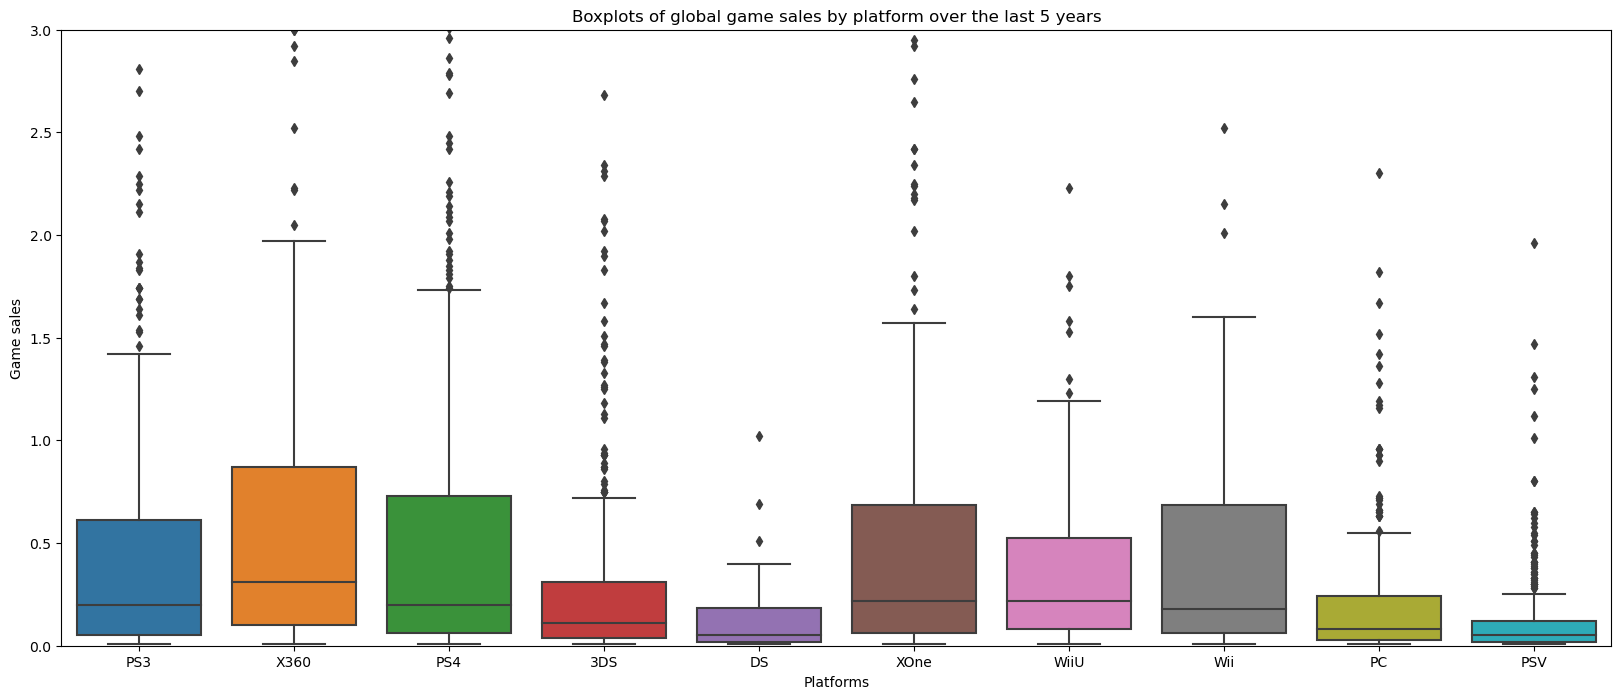

In [33]:
df_5_years1 = df[(df['year_of_release'] >= 2012) & (df['platform'].isin(platforms_top.index))]
plt.figure(figsize=(20,8))

ax = sns.boxplot(x='platform', y='total_sales', 
                 data=df_5_years1)

plt.ylim(0, 3)
ax.set_ylabel('Game sales')
ax.set_xlabel('Platforms')
ax.set_title('Boxplots of global game sales by platform over the last 5 years');

Let’s look at the same chart without scaling to examine all outliers in the data.

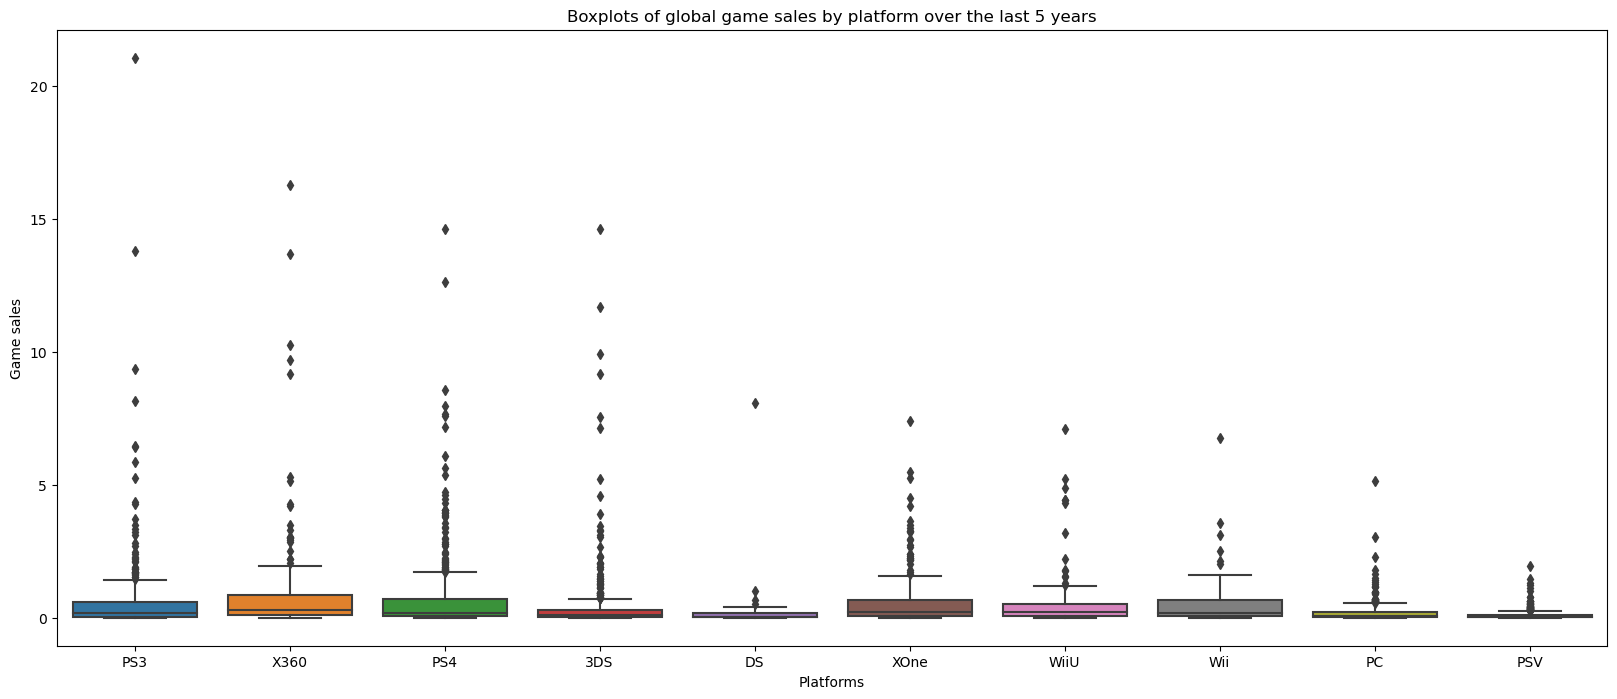

In [34]:
df_5_years1 = df[(df['year_of_release'] >= 2012) & (df['platform'].isin(platforms_top.index))]
plt.figure(figsize=(20,8))

ax = sns.boxplot(x='platform', y='total_sales', 
                 data=df_5_years1)

ax.set_ylabel('Game sales')
ax.set_xlabel('Platforms')
ax.set_title('Boxplots of global game sales by platform over the last 5 years');

The charts show that the highest sales over the past 5 years were for the X360, PS4, PS3, and Wii platforms. This is consistent with the data obtained from the catplot.

#### - How user and critic reviews affect sales

Let’s examine how user and critic reviews influence sales within the PS3, X360, PS4, XOne, and WiiU platforms (the most popular over the last 5 years). We will iterate through dataframes containing separate subsets of data for each of the five platforms and build scatter plots.

Let’s build scatter plots showing the relationship between user ratings and sales volume for the five platforms:

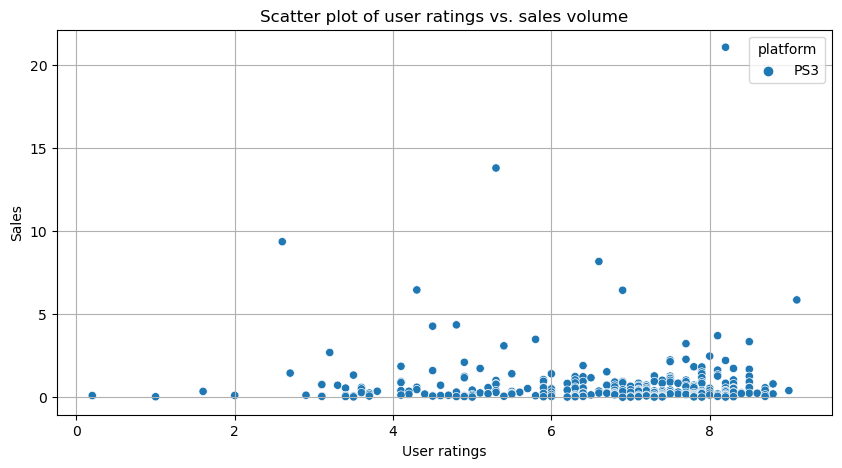

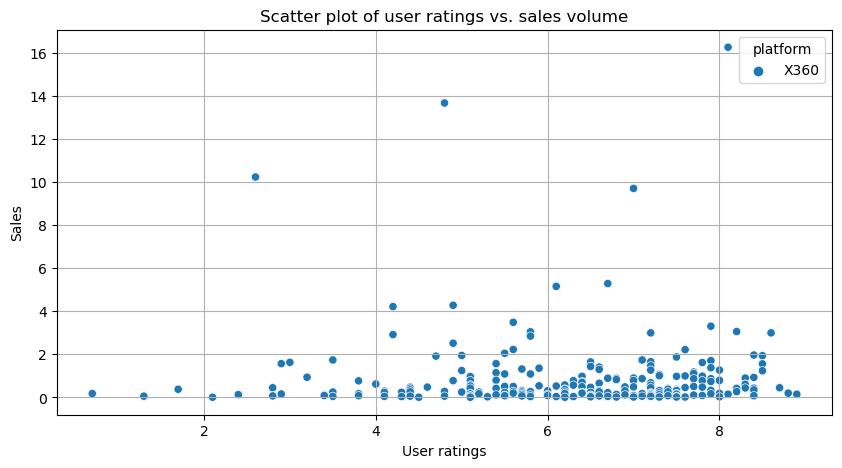

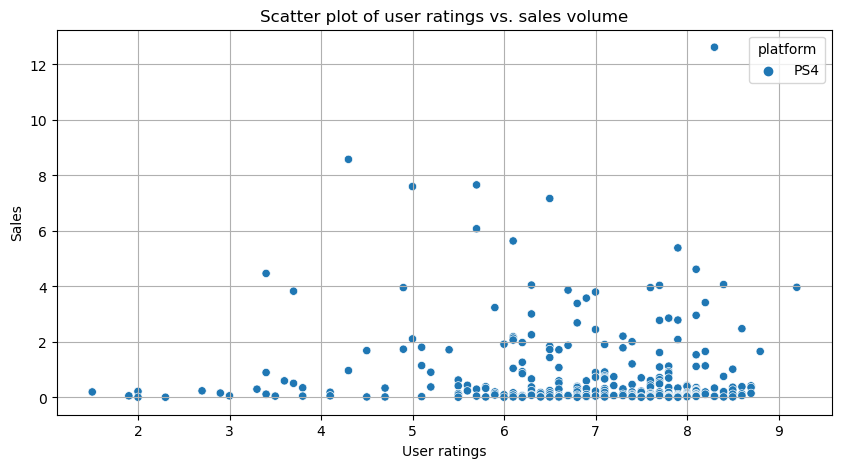

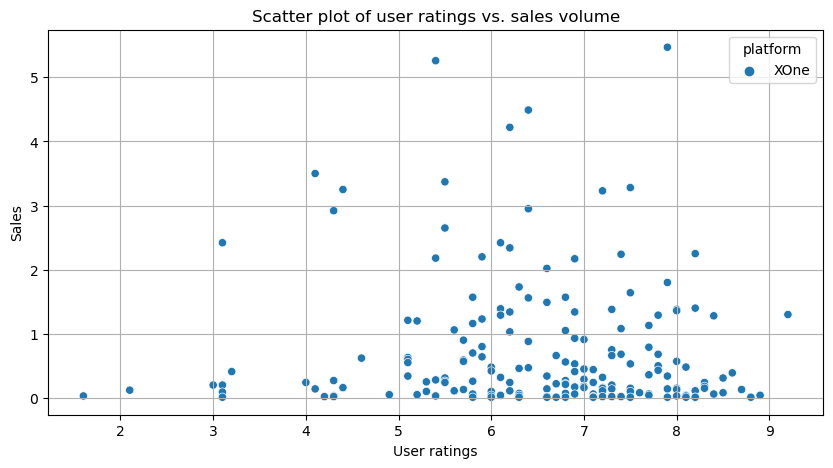

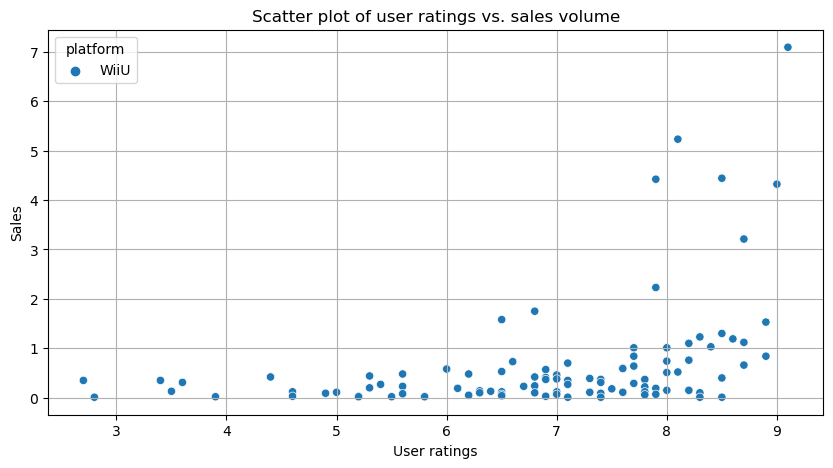

In [35]:
dfs = [(df[(df['year_of_release'] >= 2012) & (df['platform'].isin(['PS3']))]),
       (df[(df['year_of_release'] >= 2012) & (df['platform'].isin(['X360']))]), 
       (df[(df['year_of_release'] >= 2012) & (df['platform'].isin(['PS4']))]),
       (df[(df['year_of_release'] >= 2012) & (df['platform'].isin(['XOne']))]),
       (df[(df['year_of_release'] >= 2012) & (df['platform'].isin(['WiiU']))])]
for df_sep in dfs: 
    plt.figure(figsize = (10, 5))
    sns.scatterplot(x='user_score', y= 'total_sales', hue='platform', data=df_sep)
    plt.title('Scatter plot of user ratings vs. sales volume')
    plt.xlabel('User ratings')
    plt.ylabel('Sales')
    plt.grid()
    plt.show()

Let’s build scatter plots showing the relationship between critic ratings and sales volume for the five platforms:

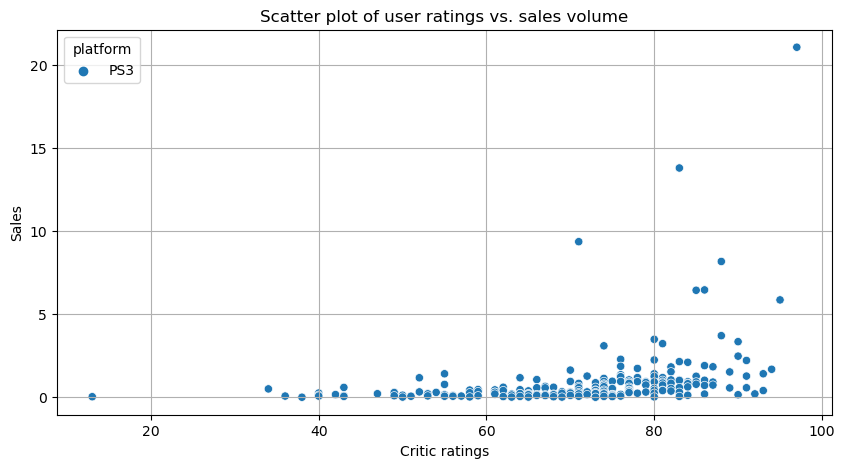

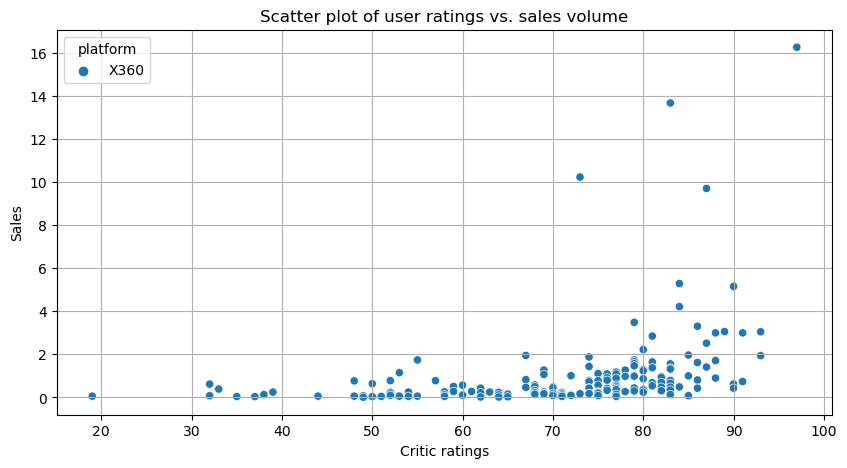

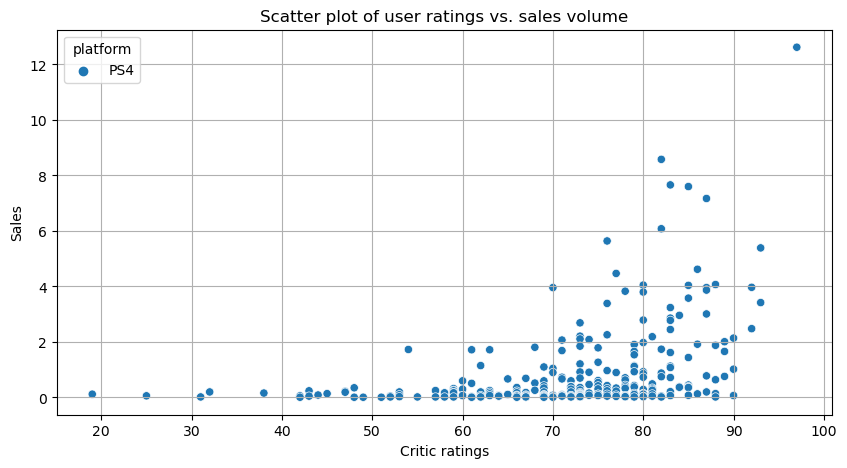

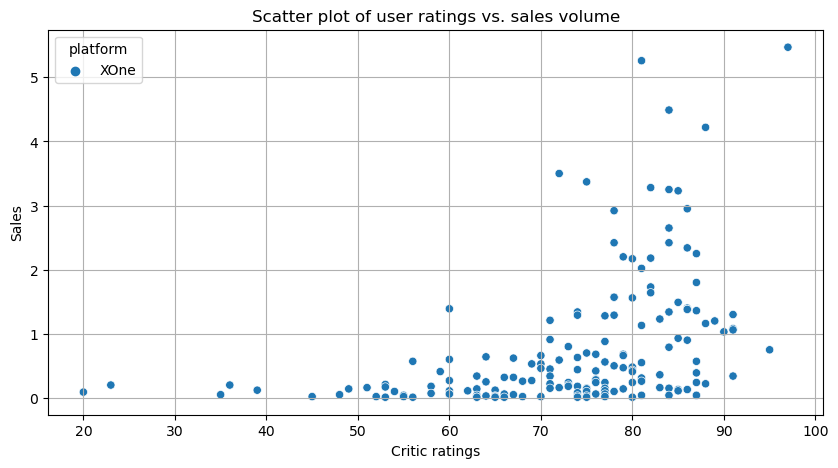

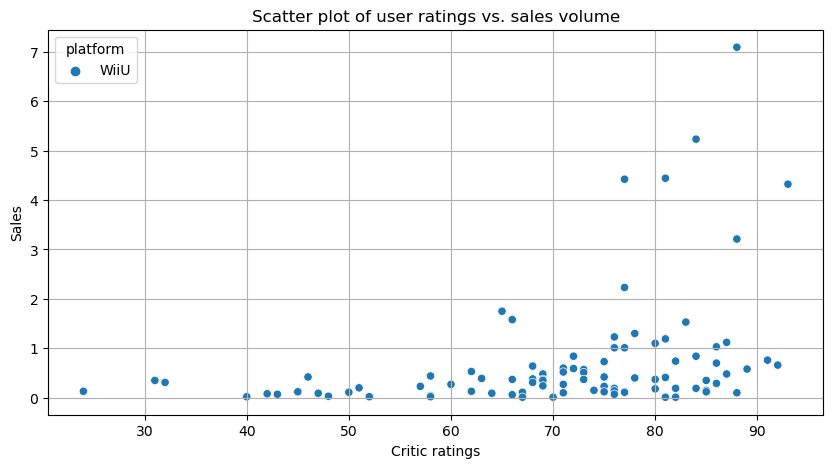

In [36]:
for df_sep in dfs: 
    plt.figure(figsize = (10, 5))
    sns.scatterplot(x='critic_score', y= 'total_sales', hue='platform', data=df_sep)
    plt.title('Scatter plot of user ratings vs. sales volume')
    plt.xlabel('Critic ratings')
    plt.ylabel('Sales')
    plt.grid()
    plt.show()

From the charts, we can see a slight tendency that the higher the platform rating, the higher the sales. This trend is more clearly visible in the chart with critic ratings. Let’s calculate the correlation for both relationships across the five platforms:

In [39]:
cor_mean = 0
for df_sep in dfs:
    platform_name = df_sep['platform'].iloc[0]
    print(f"{platform_name}:{round(df_sep['user_score'].corr(df_sep['total_sales']), 3)}")
    cor_mean += round(df_sep['user_score'].corr(df_sep['total_sales']), 3)
print(round(cor_mean / 5, 3), '- mean correlation')

PS3:-0.004
X360:0.006
PS4:-0.032
XOne:-0.069
WiiU:0.4
0.06 - mean correlation


In [40]:
cor_mean1 = 0
for df_sep in dfs:
    platform_name = df_sep['platform'].iloc[0]
    print(f"{platform_name}:{round(df_sep['critic_score'].corr(df_sep['total_sales']), 3)}")
    cor_mean1 += round(df_sep['critic_score'].corr(df_sep['total_sales']), 3)
print(round(cor_mean1 / 5, 3), '- mean correlation')

PS3:0.332
X360:0.361
PS4:0.407
XOne:0.417
WiiU:0.348
0.373 - mean correlation


First, let’s look at the correlation between user ratings and sales for the platforms: it is so small that we can say it is practically nonexistent (to evaluate its magnitude, we look at the average correlation across the five platforms). However, the correlation between critic ratings and sales is quite noticeable. Let’s examine the correlation between ratings and sales across all platforms:

In [26]:
df[df['year_of_release'] >= 2012]['user_score'].corr(df[df['year_of_release'] >= 2012]['total_sales'])

0.004804036421935466

In [27]:
df[df['year_of_release'] >= 2012]['critic_score'].corr(df[df['year_of_release'] >= 2012]['total_sales'])

0.3081185529355488

After calculating the correlation, it becomes clear that critic ratings influence sales more than user ratings. The Pearson's correlation coefficient between critic ratings and sales is higher than that between user ratings and sales. This means that the first relationship is stronger; however, overall the correlation is still relatively small in both cases.

#### - Overall distribution of games by genre

First, let’s examine the distribution of genres by popularity over the last five years:

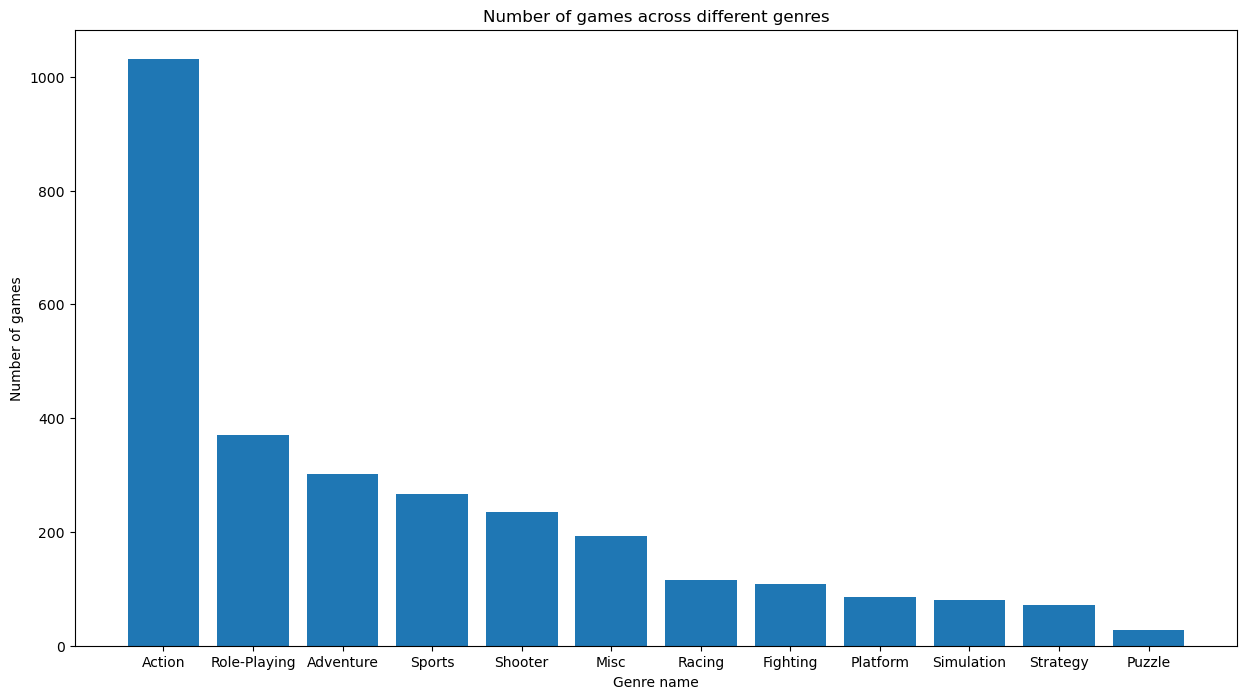

In [41]:
plt.figure(figsize=(15, 8))
plt.bar(df[df['year_of_release'] >= 2012]['genre'].value_counts().index,
        df[df['year_of_release'] >= 2012]['genre'].value_counts().values)
plt.title('Number of games across different genres')
plt.xlabel('Genre name')
plt.ylabel('Number of games');

The most popular genre is Action, and the least popular is Puzzle.

genre
Strategy         172.57
Adventure        233.33
Puzzle           239.89
Simulation       387.96
Fighting         442.66
Racing           723.49
Misc             790.29
Platform         825.55
Role-Playing     931.08
Shooter         1041.36
Sports          1307.10
Action          1716.52
Name: total_sales, dtype: float64

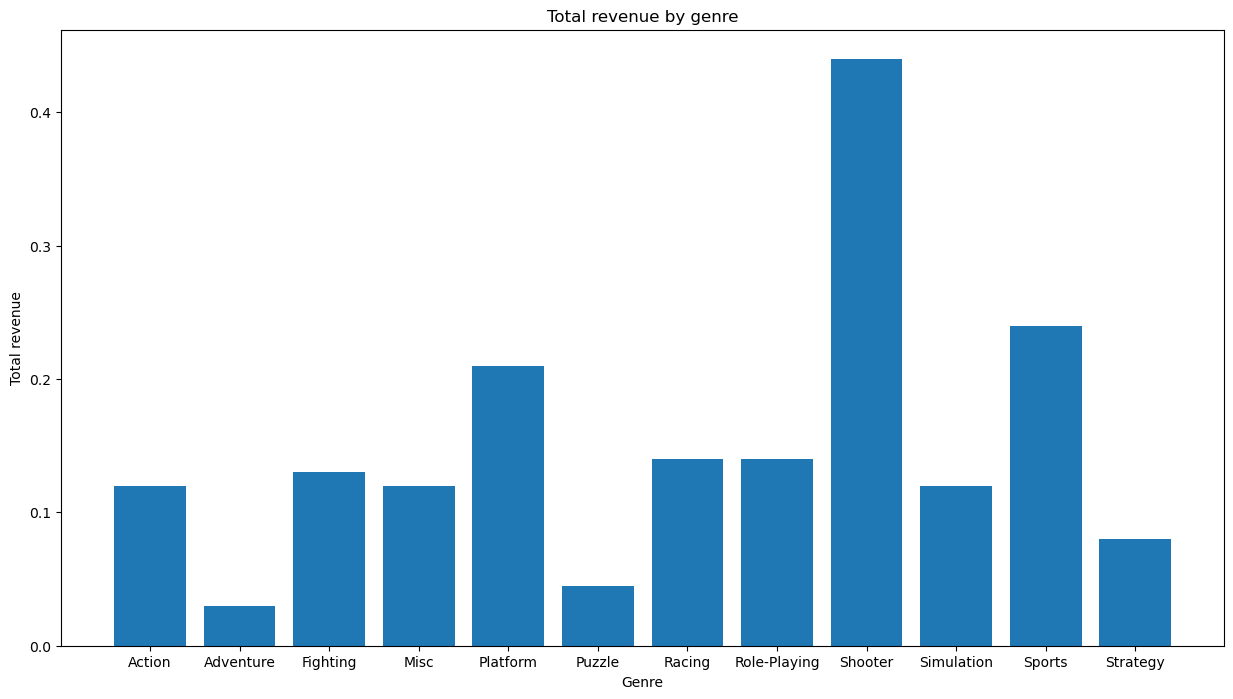

In [42]:
plt.figure(figsize=(15, 8))
plt.bar(df[df['year_of_release'] >= 2012].groupby('genre')['total_sales'].median().index,
        df[df['year_of_release'] >= 2012].groupby('genre')['total_sales'].median().values)
plt.title('Total revenue by genre')
plt.xlabel('Genre')
plt.ylabel('Total revenue')
df.groupby('genre')['total_sales'].sum().sort_values()

The highest revenue is generated by the Shooter genre; Sports and Platform are also profitable genres. The least profitable genres are Puzzle, Adventure, and Strategy.

Let’s build boxplots to once again examine the highest-grossing genres (we will look at medians and consider outliers that could have affected the statistics if we had used the mean instead of the median).

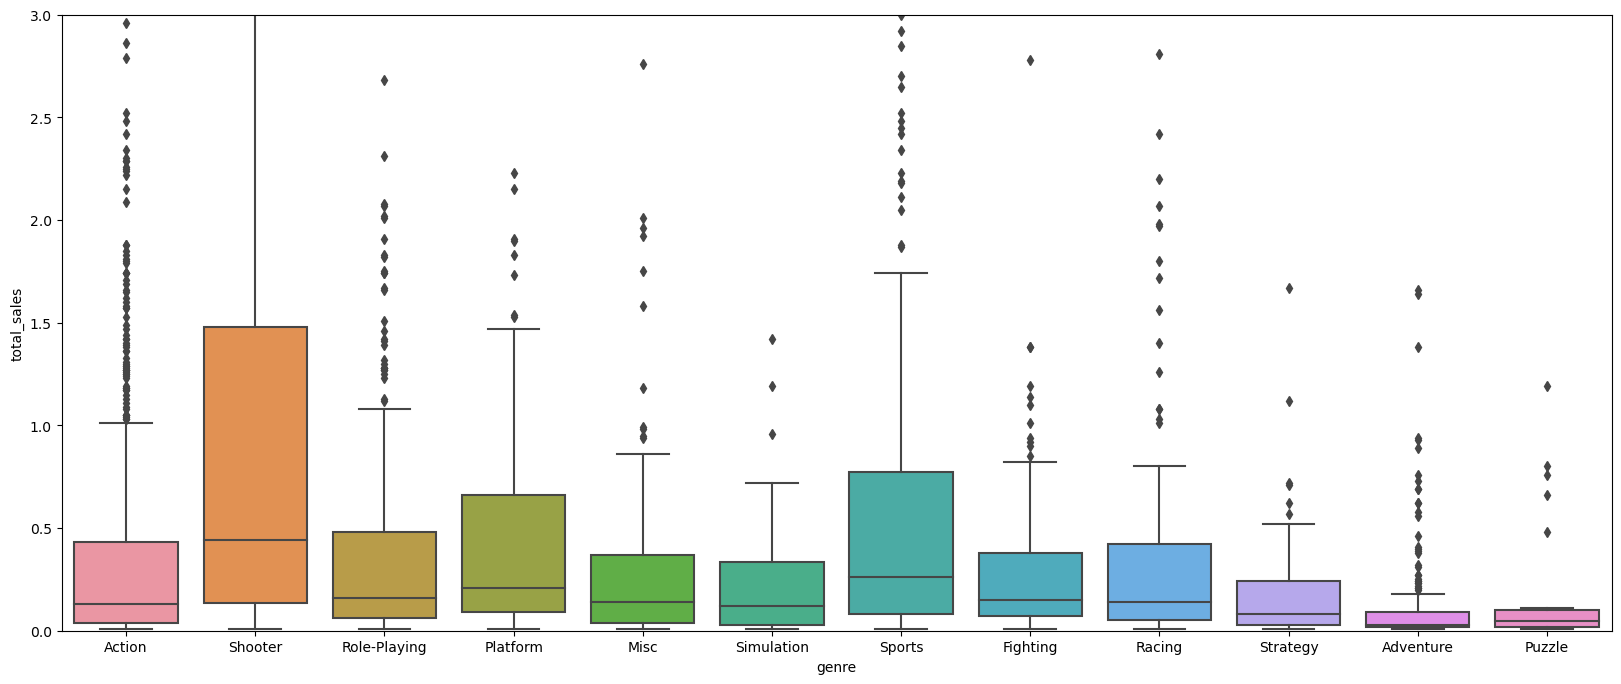

In [43]:
plt.figure(figsize=(20,8))
sns.boxplot(x='genre', y='total_sales', data=df_5_years1)

plt.ylim(0, 3)
ax.set_ylabel('Game sales')
ax.set_xlabel('Genres')
ax.set_title('Boxplots of global game sales by genre over the last 5 years');

The chart confirms the leading positions of the Shooter, Sports, and Platform genres.

### Step 4. Create a user profile for each region

#### - The most popular genres and platforms for users from North America

Top 5 most popular platforms in North America:

In [44]:
df_na = df[(df['year_of_release'] >= 2012)].groupby('platform')['na_sales'].sum().sort_values().tail()
df_na

platform
3DS      55.31
XOne     93.12
PS3     101.27
PS4     108.74
X360    140.05
Name: na_sales, dtype: float64

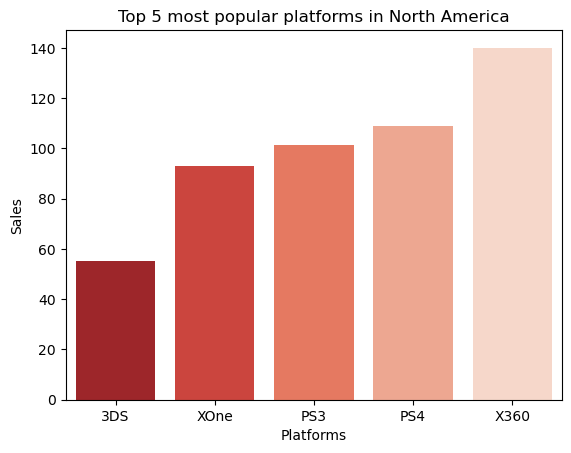

In [45]:
sns.barplot(y=df_na.values, x=df_na.index, palette = 'Reds_r')
plt.title('Top 5 most popular platforms in North America')
plt.xlabel('Platforms')
plt.ylabel('Sales');

Top 5 most popular game genres in North America:

In [46]:
df_na1 = df[(df['year_of_release'] >= 2012)].groupby('genre')['na_sales'].sum().sort_values().tail()
df_na1

genre
Misc             38.19
Role-Playing     64.00
Sports           79.42
Shooter         144.77
Action          177.84
Name: na_sales, dtype: float64

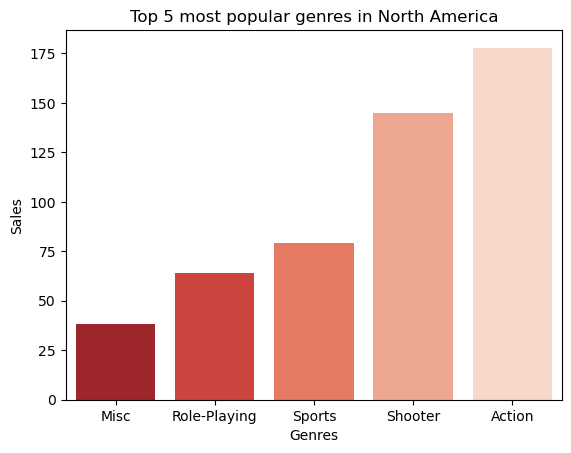

In [47]:
sns.barplot(y=df_na1.values, x=df_na1.index, palette = 'Reds_r')
plt.title('Top 5 most popular genres in North America')
plt.xlabel('Genres')
plt.ylabel('Sales');

It turns out that the most popular platform in North America is X360.
The most popular genre is Action.

#### - The most popular genres and platforms for users from Europe

Top 5 most popular platforms in Europe:

In [48]:
df_eu = df[(df['year_of_release'] >= 2012)].groupby('platform')['eu_sales'].sum().sort_values().tail()
df_eu

platform
3DS      42.64
XOne     51.59
X360     74.52
PS3     106.63
PS4     141.09
Name: eu_sales, dtype: float64

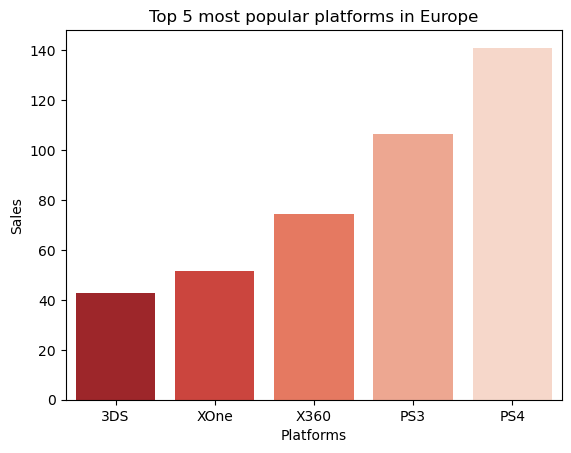

In [49]:
sns.barplot(y=df_eu.values, x=df_eu.index, palette = 'Reds_r')
plt.title('Top 5 most popular platforms in Europe')
plt.xlabel('Platforms')
plt.ylabel('Sales');

Top 5 most popular genres in Europe:

In [50]:
df_eu1 = df[(df['year_of_release'] >= 2012)].groupby('genre')['eu_sales'].sum().sort_values().tail()
df_eu1

genre
Racing           27.29
Role-Playing     48.53
Sports           68.86
Shooter         113.47
Action          159.34
Name: eu_sales, dtype: float64

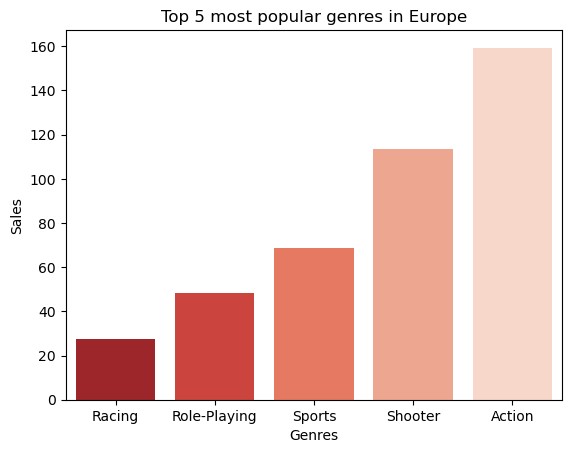

In [51]:
sns.barplot(y=df_eu1.values, x=df_eu1.index, palette = 'Reds_r')
plt.title('Top 5 most popular genres in Europe')
plt.xlabel('Genres')
plt.ylabel('Sales');

The most popular platform in Europe is PS4, and the most popular genre in Europe is Action.

#### - The most popular genres and platforms for users from Japan

Top 5 most popular platforms in Japan:

In [52]:
df_jp = df[(df['year_of_release'] >= 2012)].groupby('platform')['jp_sales'].sum().sort_values().tail()
df_jp

platform
WiiU    13.01
PS4     15.96
PSV     21.04
PS3     35.29
3DS     87.79
Name: jp_sales, dtype: float64

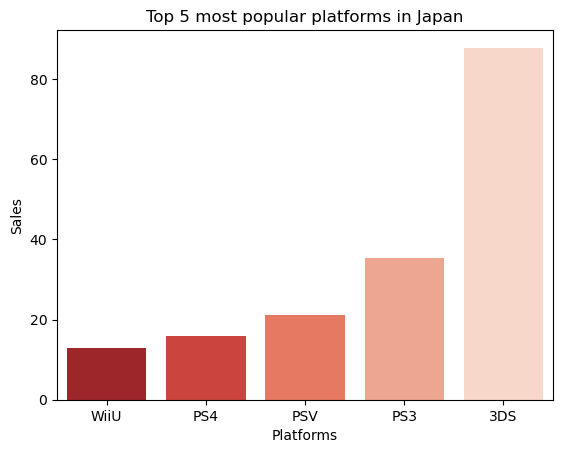

In [53]:
sns.barplot(y=df_jp.values, x=df_jp.index, palette = 'Reds_r')
plt.title('Top 5 most popular platforms in Japan')
plt.xlabel('Platforms')
plt.ylabel('Sales');

Top 5 most popular genres in Japan:

In [54]:
df_jp1 = df[(df['year_of_release'] >= 2012)].groupby('genre')['jp_sales'].sum().sort_values().tail()
df_jp1

genre
Fighting         9.44
Simulation      10.41
Misc            12.86
Action          52.80
Role-Playing    65.44
Name: jp_sales, dtype: float64

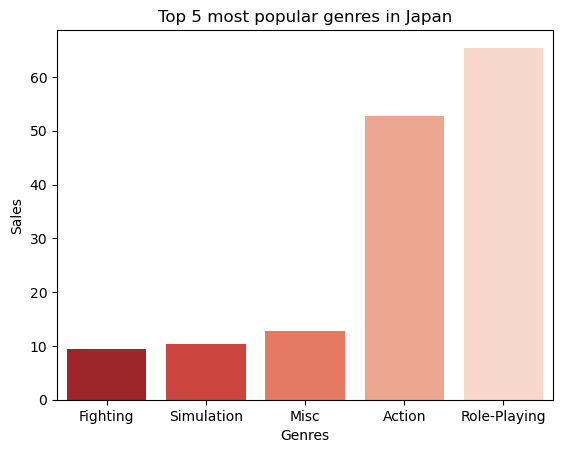

In [55]:
sns.barplot(y=df_jp1.values, x=df_jp1.index, palette = 'Reds_r')
plt.title('Top 5 most popular genres in Japan')
plt.xlabel('Genres')
plt.ylabel('Sales');

The most popular platform in Japan is 3DS, and the most popular genre in Japan is Role-Playing.

#### - Does the ESRB rating affect sales in a particular region?

- North America

In [57]:
na_rating_df = df[df['year_of_release']>=2012].groupby('rating')['na_sales'].sum().sort_values()
na_rating_df

rating
T                 66.02
E10+              75.70
not mentioned    103.31
E                112.26
M                231.57
Name: na_sales, dtype: float64

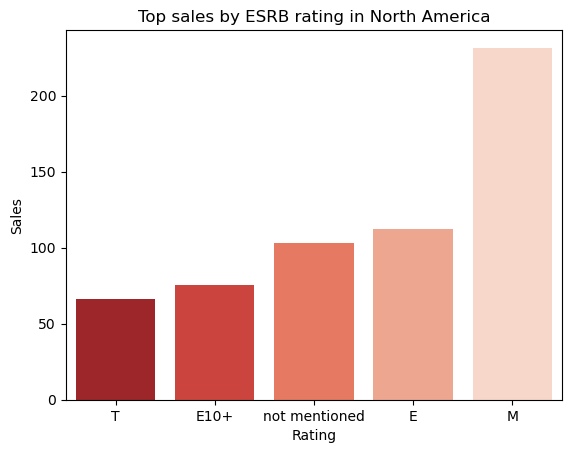

In [58]:
sns.barplot(y=na_rating_df.values, x=na_rating_df.index, palette = 'Reds_r')
plt.title('Top sales by ESRB rating in North America')
plt.xlabel('Rating')
plt.ylabel('Sales');

- Europe

In [59]:
eu_rating_df = df[df['year_of_release']>=2012].groupby('rating')['eu_sales'].sum().sort_values()
eu_rating_df

rating
T                 52.96
E10+              55.37
not mentioned     91.50
E                112.80
M                193.96
Name: eu_sales, dtype: float64

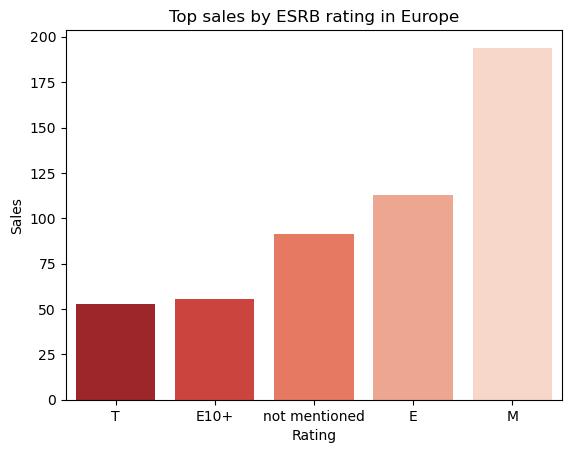

In [60]:
sns.barplot(y=eu_rating_df.values, x=eu_rating_df.index, palette = 'Reds_r')
plt.title('Top sales by ESRB rating in Europe')
plt.xlabel('Rating')
plt.ylabel('Sales');

- Japan

In [61]:
jp_rating_df = df[df['year_of_release']>=2012].groupby('rating')['jp_sales'].sum().sort_values()
jp_rating_df

rating
E10+               8.19
M                 21.20
T                 26.02
E                 28.33
not mentioned    108.84
Name: jp_sales, dtype: float64

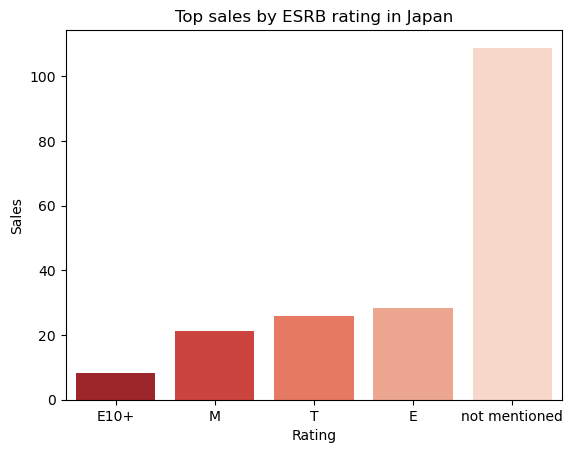

In [62]:
sns.barplot(y=jp_rating_df.values, x=jp_rating_df.index, palette = 'Reds_r')
plt.title('Top sales by ESRB rating in Japan')
plt.xlabel('Rating')
plt.ylabel('Sales');

The charts show that the ESRB rating affects sales everywhere except Japan, because in Japan the best-selling games are those without a rating.

### Step 5. Test the hypotheses

#### -  Average user ratings of Xbox One and PC platforms are equal

First, we formulate the hypotheses. The null hypothesis must be formulated as equality. Since the hypothesis is two-sided, the alternative hypothesis is formulated as inequality:

- H0: "The average user ratings of Xbox One and PC platforms are equal."
- H1: "The average user ratings of Xbox One and PC platforms are not equal."

Let’s take the significance level α = 0.05. We will calculate the p-value using an appropriate test and compare it with the significance level.

- If p-value < α, we reject the null hypothesis in favor of the alternative.
- If p-value > α, we fail to reject the null hypothesis.

We will test the two-sided hypothesis about the equality of means of two independent samples (using the function st.ttest_ind()). We add the parameter equal_var=False because we cannot assume equal variances of the samples.

In [64]:
alpha = 0.05

In [65]:
df_xone = df[(df['year_of_release'] >= 2012) & (df['platform'] == 'XOne')]
df_pc = df[(df['year_of_release'] >= 2012) & (df['platform'] == 'PC')]

results = st.ttest_ind(df_xone['user_score'].dropna().reset_index(drop=True),
                       df_pc['user_score'].dropna().reset_index(drop=True), equal_var=False)
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Failed to reject the null hypothesis') 

p-value: 0.5489537965134912
Failed to reject the null hypothesis


The test showed that we failed to reject the null hypothesis. Therefore, we accept that the average user ratings of Xbox One and PC platforms are equal.

In [66]:
df_5_years1.groupby('platform')['user_score'].mean()

platform
3DS     7.033333
DS      7.000000
PC      6.428641
PS3     6.540214
PS4     6.748249
PSV     7.410000
Wii     6.082353
WiiU    6.904000
X360    6.220851
XOne    6.521429
Name: user_score, dtype: float64

The average user ratings confirm our conclusion: 6.52 and 6.42 are close values. Considering statistical randomness, they can be treated as equal.

#### - Average user ratings of Action and Sports genres are different

First, let’s formulate the hypotheses. We are comparing two mean values, and we need to determine whether they are different. The null hypothesis must be formulated as equality. Since the hypothesis is two-sided, the alternative hypothesis is formulated as inequality:

- H0: “The average user ratings of the Action and Sports genres are equal.”
- H1: “The average user ratings of the Action and Sports genres are not equal.”

We set the significance level α = 0.05. We calculate the p-value using an appropriate test and compare it with the significance level.

- If p-value < α, we reject the null hypothesis in favor of the alternative.
- If p-value > α, we fail to reject the null hypothesis.

We test the two-sided hypothesis about equality of means of two independent samples (using the function st.ttest_ind()). The samples are independent because a game cannot belong to two genres at the same time — it always belongs to one genre — therefore, the samples do not overlap.

We add the parameter equal_var=False because we cannot assume equal variances.

In [67]:
df_action = df[(df['year_of_release'] >= 2012) & (df['genre'] == 'Action')]
df_sports = df[(df['year_of_release'] >= 2012) & (df['genre'] == 'Sports')]

results = st.ttest_ind(df_action['user_score'].dropna().reset_index(drop=True),
                       df_sports['user_score'].dropna().reset_index(drop=True), equal_var=False)
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Reject the null hypothesis')
else:
    print('Failed to reject the null hypothesis')

p-value: 8.449849446620471e-20
Reject the null hypothesis


The test showed that, based on the available data and at the 5% significance level, the null hypothesis should be rejected in favor of the alternative. This means that the average user ratings of the Action and Sports genres are statistically different.

In [68]:
df_5_years1.groupby('genre')['user_score'].mean()

genre
Action          6.831992
Adventure       7.466667
Fighting        6.895714
Misc            6.938806
Platform        6.806061
Puzzle          7.633333
Racing          6.151163
Role-Playing    7.242604
Shooter         6.435897
Simulation      6.511905
Sports          5.466146
Strategy        6.420000
Name: user_score, dtype: float64

The average user ratings confirm our conclusion: 6.83 and 5.46 are not close values, so they should not be considered equal.

### Step 6. Overall Conclusion

The goal of the project was to identify patterns that determine a game's success in order to focus on potentially popular products and plan advertising campaigns for the upcoming year.

In the first step of the project, I obtained general information about the dataset, developed an understanding of how the tables were structured, identified obvious shortcomings, and outlined a data preprocessing plan.

In the second step, I performed data preprocessing: I renamed the columns to make them easier to work with. Then I handled missing values — some were removed, some were replaced, and some were left unchanged — based on the main goal of obtaining statistics that accurately reflect reality. After that, I converted data types where necessary to make the data easier to analyze. I also created a new column containing total sales across all regions, which was later used in the analysis.

In the third step, I conducted exploratory data analysis. First, I examined how many games were released in different years and analyzed market trends in the video game industry. It turned out that during the analyzed period, the market was declining. Then I built a chart to see how sales changed across platforms. I found that from the time a platform appears on the market to its disappearance, it typically lasts about 7–9 years. I then identified the relevant period for forecasting 2017 and selected the last 5 years for analysis. After that, I analyzed which platforms led in sales during this period and examined market dynamics. I concluded that by 2016, all platforms were losing popularity, with PS4 being the only platform that remained popular.

Next, after building box plots, I confirmed that in 2016 sales across all platforms significantly decreased. I also analyzed the correlation between sales and critic/user ratings. It turned out that critic scores influence sales more than user scores, which seems logical. Finally, I determined that the most profitable genres are Shooter, Sports, and Platform.

In the fourth step, I created a profile of users in each region. I found that the most popular platform in North America is Xbox 360, and the most popular genre is Action. In Europe, the most popular platform is PS4, and the most popular genre is Action. In Japan, the most popular platform is 3DS, and the most popular genre is Role-Playing. I also found that ESRB ratings affect sales more in North America and Europe than in Japan.

In the fifth and final step, I tested hypotheses by formulating null and alternative hypotheses and conducting t-tests. I found that the average user ratings for Xbox One and PC are equal, while the average user ratings for the Action and Sports genres are not equal.

The project goal was achieved. I identified many patterns that determine the success of games and analyzed the video game market based on key parameters over the past five years. The obtained information will help predict the market situation in 2017, allowing for more effective marketing campaigns and potentially increasing sales.

In my opinion, marketers should pay attention to Shooter and Sports genres, as they may generate the highest profits in 2017. I also believe that focusing on games for the PS4 platform is advisable, as it generated the highest profit in 2016. ESRB ratings and user scores should not be given excessive importance, but critic reviews should be considered carefully.